# Stellar Classification Project using SDSS17

## Project Overview
In astronomy, stellar classification is the classification of stars based on their spectral characteristics. The classification scheme of galaxies, quasars, and stars is one of the most fundamental in astronomy. This project aims to classify space observations into stars, galaxies, or quasars based on their spectral footprints captured by the Sloan Digital Sky Survey (SDSS).

## Dataset Selection & Rationale
We selected the **Stellar Classification Dataset - SDSS17** because of its substantial scale and completeness. **The data contains 100000 observations with 18 attributes**, making it an exceptional candidate for training high-capacity, robust Machine Learning classifiers.

## Attribute Definitions
The dataset comprises 17 feature columns and 1 target class column:
* **obj_ID**: Object Identifier, the unique value that identifies the object in the image catalog.
* **alpha**: Right Ascension angle (at J2000 epoch).
* **delta**: Declination angle (at J2000 epoch).
* **u**: Ultraviolet filter in the photometric system.
* **g**: Green filter in the photometric system.
* **r**: Red filter in the photometric system.
* **i**: Near Infrared filter in the photometric system.
* **z**: Infrared filter in the photometric system.
* **run_ID**: Run Number used to identify the specific scan.
* **rerun_ID**: Rerun Number to specify how the image was processed.
* **cam_col**: Camera column to identify the scanline within the run.
* **field_ID**: Field number to identify each field.
* **spec_obj_ID**: Unique ID used for optical spectroscopic objects.
* **class**: Object class (GALAXY, STAR, or QSO/Quasar object) -> **Target Variable**.
* **redshift**: Redshift value based on the increase in wavelength.
* **plate**: Plate ID, identifies each plate in SDSS.
* **MJD**: Modified Julian Date, indicating when the SDSS data was captured.
* **fiber_ID**: Fiber ID identifying the fiber that pointed light at the focal plane.


## Automated Data Acquisition
Instead of manual downloads, we use the `kagglehub` library to fetch the official and latest version of the Stellar Classification Dataset (SDSS17) directly from Kaggle.


In [2]:
import os
import kagglehub
import pandas as pd

# Download latest version of the dataset
print("Downloading dataset from Kaggle...")
download_path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

# Identify the target CSV file inside the downloaded directory
csv_files = [f for f in os.listdir(download_path) if f.endswith('.csv')]
if csv_files:
    target_csv = os.path.join(download_path, csv_files[0])
    df = pd.read_csv(target_csv)
    print(f"Successfully loaded '{csv_files[0]}' into DataFrame.")
else:
    raise FileNotFoundError("No CSV file found in the downloaded directory.")

# Confirm the expected structural properties
print(f"Dataset contains {df.shape[0]} observations and {df.shape[1]} attributes.")


Successfully loaded 'star_classification.csv' into DataFrame.
Dataset contains 100000 observations and 18 attributes.


In [3]:
# Display dataset structure details
print("--- Features Information ---")
print(df.info())

print("\n--- Class Balance (Target Variable) ---")
print(df['class'].value_counts())

# View a sample of the raw observations
df.head()


--- Features Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
d

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


## Exploratory Data Analysis (EDA)

### Data Integrity Check
Before analyzing patterns, we must verify the structural integrity of the dataset. This includes checking for:
* Missing or null values across all columns.
* Duplicate observations that could skew model training.
* Unique counts to identify constants or redundant high-cardinality identifiers.


In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("--- Missing Values Per Column ---")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")

# Check for identical duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Check unique values to identify columns with single values or IDs
print("\n--- Unique Values Count Per Feature ---")
print(df.nunique())


--- Missing Values Per Column ---
No missing values found.

Number of duplicate rows: 0

--- Unique Values Count Per Feature ---
obj_ID          78053
alpha           99999
delta           99999
u               93748
g               92651
r               91901
i               92019
z               92007
run_ID            430
rerun_ID            1
cam_col             6
field_ID          856
spec_obj_ID    100000
class               3
redshift        99295
plate            6284
MJD              2180
fiber_ID         1000
dtype: int64


### Target Variable Distribution Analysis
The `class` column represents our target variable, containing three categories: `GALAXY`, `STAR`, and `QSO` (Quasar). We will evaluate the class distribution to check for imbalance, which directly impacts our choice of evaluation metrics (e.g., macro F1-score vs. accuracy).


--- Class Distribution ---
GALAXY: 59445 rows (59.45%)
STAR: 21594 rows (21.59%)
QSO: 18961 rows (18.96%)


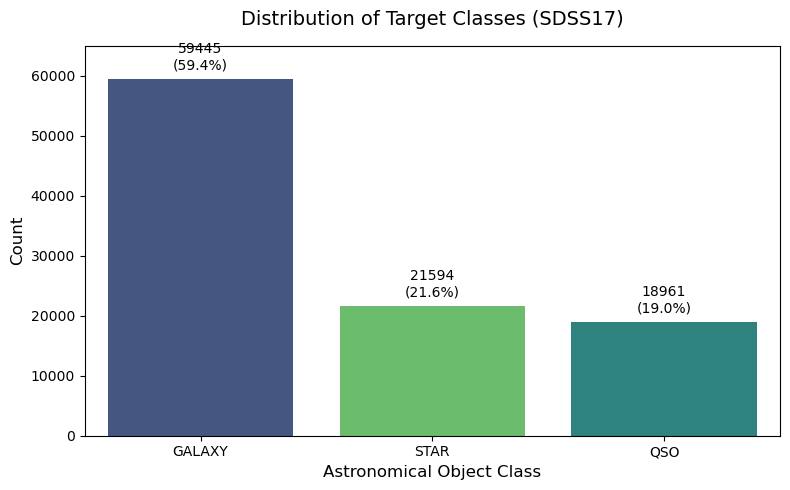

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate absolute counts and relative percentages
class_counts = df['class'].value_counts()
class_percentages = df['class'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
for idx, (count, pct) in enumerate(zip(class_counts, class_percentages)):
    print(f"{class_counts.index[idx]}: {count} rows ({pct:.2f}%)")

# Setup the visualization canvas
fig, ax = plt.subplots(figsize=(8, 5))

# Create a countplot with explicit hue mapping to eliminate Seaborn warnings
sns.countplot(
    x='class', 
    data=df, 
    order=class_counts.index, 
    hue='class', 
    palette='viridis', 
    legend=False, 
    ax=ax
)

# Customize plot titles, labels, and limits
ax.set_title('Distribution of Target Classes (SDSS17)', fontsize=14, pad=15)
ax.set_xlabel('Astronomical Object Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, 65000)

# Annotate values on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Ensure valid bars are annotated
        percentage = (height / len(df)) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()
